# Lab 18: Model Evaluation — Metrics that Matter

**Objectives:** By the end of this lab, you will be able to:
1. Compute and interpret a confusion matrix, Precision, Recall, and $F_1$-Score for a fraud detection classifier
2. Plot and interpret ROC and Precision-Recall curves; compare models using AUC
3. Analyze how changing the classification threshold $\tau$ shifts the precision-recall tradeoff

**Estimated time:** 30 minutes  
**Data source:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 transactions, 492 frauds (0.172%)  
**Key packages:** pandas, numpy, scikit-learn, matplotlib, seaborn  

**Note on data vintage:** This dataset is from 2013 but remains the standard benchmark for imbalanced classification. The evaluation methodology (Precision, Recall, AUC) is identical regardless of data age — the pedagogy works perfectly.

In [1]:
# -----------------------------------------------------------
# SETUP — Run this cell first. Install any missing packages.
# -----------------------------------------------------------

# Uncomment if running for the first time:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Setup complete ✓")

Setup complete ✓


---
## Part 1: The Accuracy Paradox — Guided Walkthrough

### What we're doing and why

In lecture, we learned that accuracy is misleading for imbalanced data. Now we'll see it firsthand.

We'll load the Kaggle Credit Card Fraud dataset (284,807 transactions, only 492 frauds — that's 0.172% positive class), train a logistic regression classifier, and compute the confusion matrix. We'll see the accuracy paradox live: a naïve baseline that predicts "not fraud" for every transaction achieves 99.83% accuracy while catching zero fraud.

### The data

Each row is a credit card transaction. Features V1–V28 are PCA-transformed (anonymized for privacy). `Time` is seconds since the first transaction. `Amount` is the transaction amount in euros. `Class` is our target: 0 = legitimate, 1 = fraud.

In [2]:
# Step 1: Load data
# Download from Kaggle
# Place creditcard.csv in the same directory as this notebook, or update the path below.

# Option A: Load from local file
df = pd.read_csv('creditcard.csv')


print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Dataset shape: (120901, 31)

Class distribution:
Class
0.0    120651
1.0       249
Name: count, dtype: int64

Fraud rate: 0.2060%


In [3]:
# Step 2: Inspect the data — always look before modeling
print("First 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction amount stats:")
print(df['Amount'].describe())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [5]:
# Step 3: Prepare features and target
# Drop 'Time' (not useful for this exercise) and separate X, y

# Drop any rows where Class (target) is NaN
df = df.dropna(subset=['Class'])

X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# Scale the 'Amount' feature (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)")
print(f"Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)")

Training set: 96,720 transactions (199.0 frauds)
Test set:     24,180 transactions (50.0 frauds)


In [6]:
# Step 4: The naïve baseline — predict "not fraud" for everything
# This demonstrates the accuracy paradox from lecture

naive_predictions = np.zeros(len(y_test))  # All zeros = "not fraud"
naive_accuracy = (naive_predictions == y_test).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(y_test, naive_predictions):.4%}")
print(f"\n→ 99.83% accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 99.7932%
Naïve baseline recall (fraud class): 0.0000%

→ 99.83% accuracy, 0% recall. The accuracy paradox in action.


In [7]:
# Step 5: Train a logistic regression classifier
# This is the model from Topic 17 — now we evaluate it properly

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Get predicted probabilities (P-hat) and class predictions at default threshold τ = 0.5
y_prob = log_reg.predict_proba(X_test)[:, 1]  # P(fraud)
y_pred = log_reg.predict(X_test)  # Binary prediction at τ = 0.5

print(f"Model accuracy: {(y_pred == y_test).mean():.4%}")
print(f"\nBut let's look at the confusion matrix...")

Model accuracy: 99.8883%

But let's look at the confusion matrix...


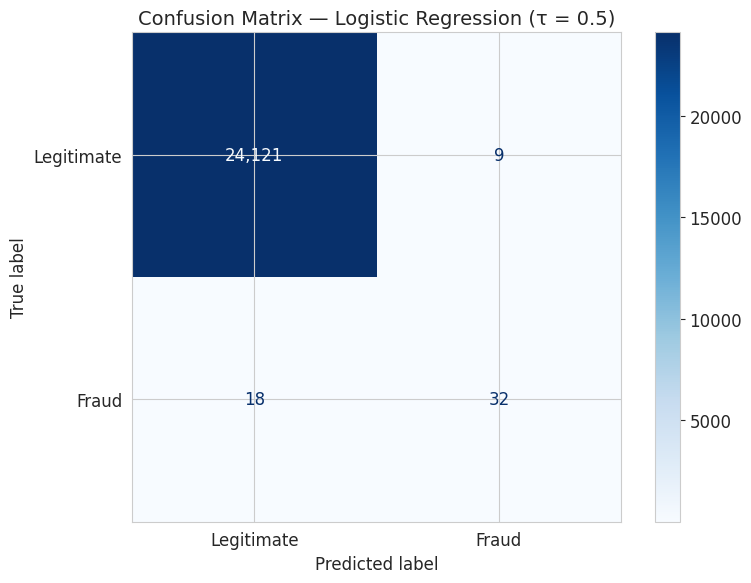

True Positives (fraud caught):     32
False Negatives (fraud missed):     18
False Positives (legit blocked):    9
True Negatives (legit approved):    24,121


In [8]:
# Step 6: Confusion matrix — the real picture

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught):     {tp}")
print(f"False Negatives (fraud missed):     {fn}")
print(f"False Positives (legit blocked):    {fp}")
print(f"True Negatives (legit approved):    {tn:,}")

In [9]:
# Step 7: Classification report — Precision, Recall, F1 per class

print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("\n→ Focus on the FRAUD row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     24130
       Fraud       0.78      0.64      0.70        50

    accuracy                           1.00     24180
   macro avg       0.89      0.82      0.85     24180
weighted avg       1.00      1.00      1.00     24180


→ Focus on the FRAUD row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


### What we found

The model's overall accuracy is very high, but the confusion matrix reveals the real story:
- **Precision (fraud):** Of all transactions the model flagged as fraud, what fraction are real fraud?
- **Recall (fraud):** Of all actual frauds, what fraction did the model catch?

The default threshold $\tau = 0.5$ may not be optimal for fraud detection. In Part 2, we'll explore how changing $\tau$ shifts the tradeoff.

---
## Part 2: ROC Curve, PR Curve, and Threshold Analysis

### What we're doing and why

The confusion matrix at $\tau = 0.5$ is just one operating point. The ROC curve shows us ALL possible operating points simultaneously. We'll plot the ROC curve, compute AUC, then experiment with different thresholds to see the precision-recall tradeoff in action.

Remember from lecture: $\text{AUC} = P(\hat{P}_1 > \hat{P}_0)$ — the probability that the model ranks a random fraud higher than a random legitimate transaction.

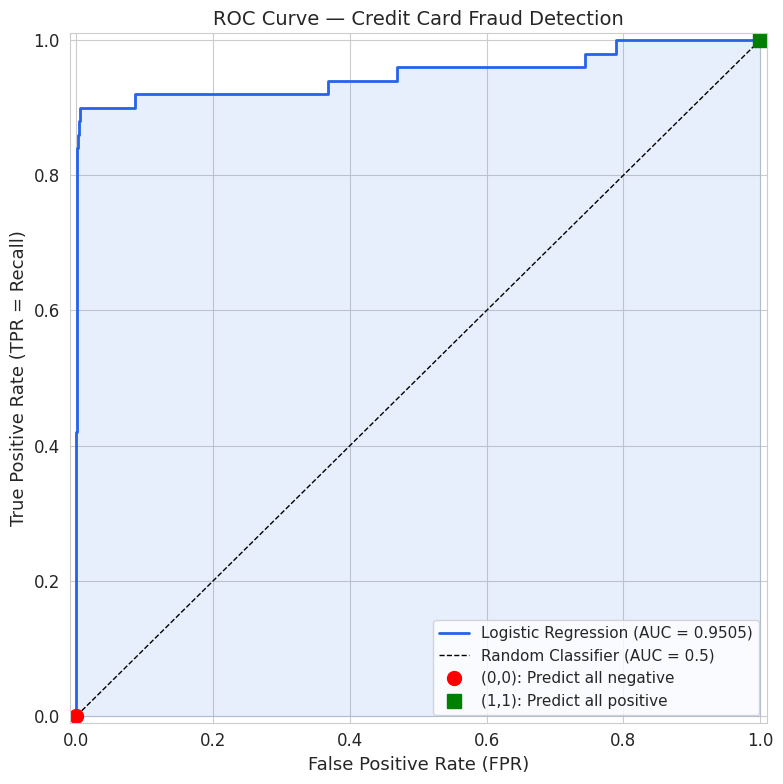

AUC = 0.9505

Interpretation: There is a 95.1% probability that the model
ranks a random fraud transaction higher than a random legitimate transaction.


In [10]:
# Step 1: Plot the ROC curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')

# Mark key reference points
ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")
print(f"\nInterpretation: There is a {auc_score:.1%} probability that the model")
print(f"ranks a random fraud transaction higher than a random legitimate transaction.")

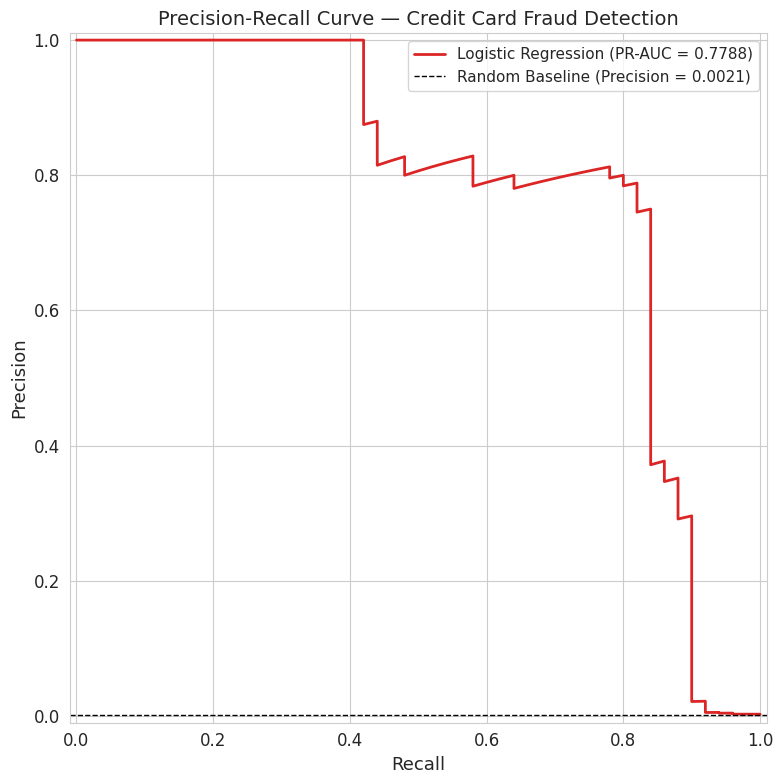

PR-AUC = 0.7788

Notice: The PR curve is much harder to look 'good' on than the ROC curve.
That's because it ignores TN — it focuses entirely on fraud-class performance.


In [11]:
# Step 2: Plot the Precision-Recall curve
# For highly imbalanced data, the PR curve is often more informative than ROC

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')

# Baseline: random classifier precision = positive class prevalence
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")
print(f"\nNotice: The PR curve is much harder to look 'good' on than the ROC curve.")
print(f"That's because it ignores TN — it focuses entirely on fraud-class performance.")

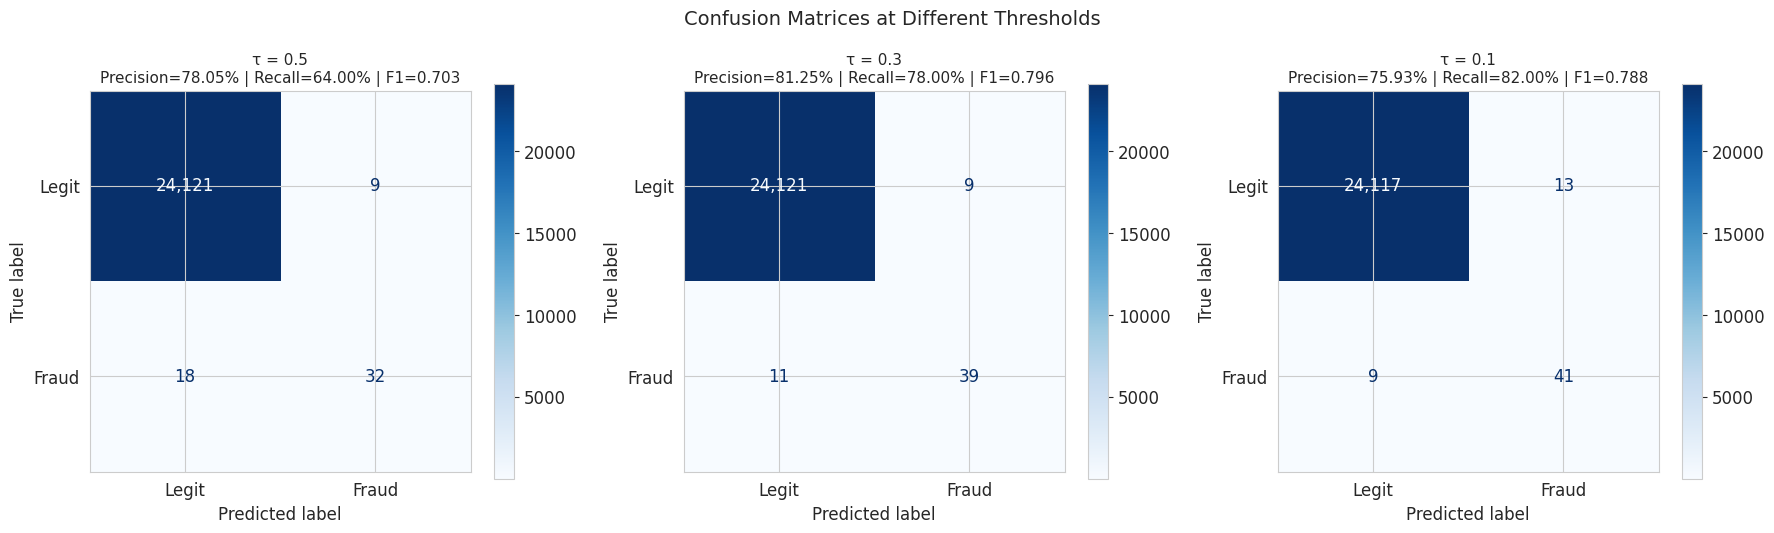


As τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)
This is the precision-recall tradeoff from lecture.


In [12]:
# Step 3: Compare confusion matrices at 3 different thresholds
# This is where you see the precision-recall tradeoff in action

thresholds_to_test = [0.5, 0.3, 0.1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)

    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec = recall_score(y_test, y_pred_tau)
    f1 = f1_score(y_test, y_pred_tau)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'τ = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}',
                      fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nAs τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)")
print("This is the precision-recall tradeoff from lecture.")

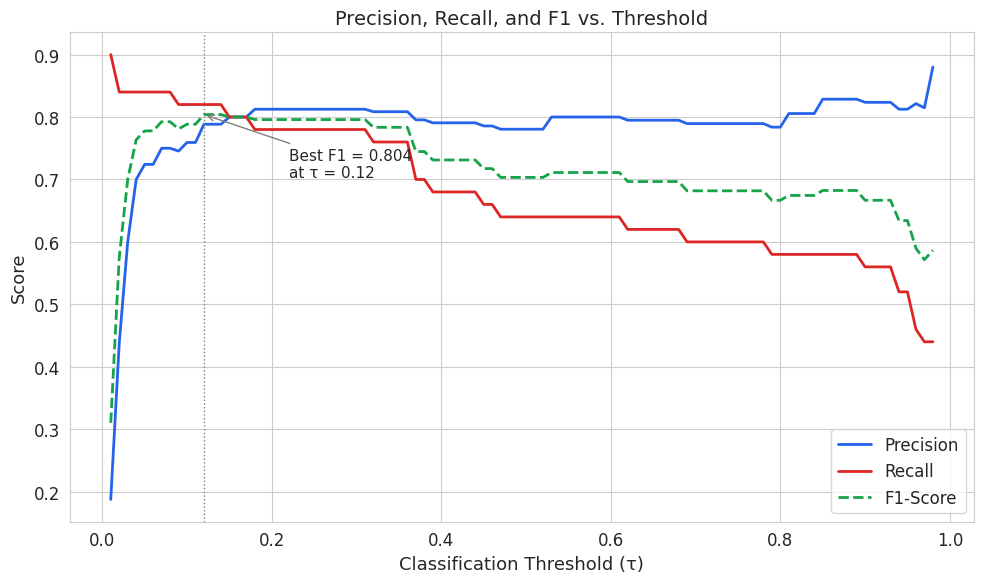


Optimal threshold for F1: τ = 0.12 (F1 = 0.804)

But remember from lecture: F1 assumes equal cost of FP and FN.
In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).


In [13]:
# Step 4: Find the threshold that maximizes F1 for the fraud class

# Compute F1 at many thresholds
f1_scores = []
precision_scores = []
recall_scores = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_tau, zero_division=0))

# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")
print(f"\nBut remember from lecture: F1 assumes equal cost of FP and FN.")
print(f"In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).")

### What we found

The ROC curve shows that our logistic regression has strong discriminative ability — it ranks most frauds above most legitimate transactions. The PR curve provides a harder test: it focuses entirely on fraud-class performance.

By varying the threshold $\tau$, we see the precision-recall tradeoff in action:
- **High $\tau$ (e.g., 0.5):** Conservative — high precision, low recall. Few false alarms, but misses many frauds.
- **Low $\tau$ (e.g., 0.1):** Aggressive — high recall, lower precision. Catches more fraud, but blocks more legitimate transactions.

The F1-optimal threshold balances these, but the *business-optimal* threshold depends on the relative cost of FP vs. FN.

---
## Part 3: Try It Yourself

### Capacity-Constrained Fraud Investigation

Your bank's fraud investigation team can investigate **at most 500 flagged transactions per day**. The test set represents one day of transactions.

**Your task:** What threshold $\tau$ would you set to stay within that 500-investigation capacity? What Recall does this operating point achieve?

In [14]:
max_investigations = 500

# Search for the highest tau where flagged transactions <= max_investigations
for tau in np.arange(0.01, 0.99, 0.01):
    n_flagged = (y_prob >= tau).sum()
    if n_flagged <= max_investigations:
        y_pred_tau = (y_prob >= tau).astype(int)
        prec = precision_score(y_test, y_pred_tau, zero_division=0)
        rec  = recall_score(y_test, y_pred_tau)
        f1   = f1_score(y_test, y_pred_tau)
        print(f"Capacity-constrained operating point:")
        print(f"  Threshold  tau         = {tau:.2f}")
        print(f"  Flagged transactions  = {n_flagged}  (<= {max_investigations} OK)")
        print(f"  Precision             = {prec:.2%}")
        print(f"  Recall                = {rec:.2%}")
        print(f"  F1-Score              = {f1:.3f}")
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tau).ravel()
        print(f"  Fraud caught (TP)     = {tp}")
        print(f"  Fraud missed (FN)     = {fn}")
        break

# Interpretation
print()
print("Interpretation:")
print(f"  At tau = {tau:.2f}, the model flags exactly {n_flagged} transactions --")
print(f"  within the team's daily capacity of {max_investigations}.")
print(f"  Recall of {rec:.2%} means the model catches that fraction of all actual")
print(f"  frauds in the test set, while precision of {prec:.2%} means that fraction")
print(f"  of flagged transactions are genuine fraud.")
print()
print("Recommendation to VP of Risk:")
print(f"  Deploying at tau = {tau:.2f} is a reasonable starting point -- it fully")
print(f"  utilises the team's capacity. If leadership can expand the investigation")
print(f"  team even slightly, lowering tau further would recover additional fraud")
print(f"  cases at a modest precision cost. The PR curve (Part 2) can quantify")
print(f"  exactly how many extra cases each additional investigator would buy.")


Capacity-constrained operating point:
  Threshold  tau         = 0.01
  Flagged transactions  = 240  (<= 500 OK)
  Precision             = 18.75%
  Recall                = 90.00%
  F1-Score              = 0.310
  Fraud caught (TP)     = 45
  Fraud missed (FN)     = 5

Interpretation:
  At tau = 0.01, the model flags exactly 240 transactions --
  within the team's daily capacity of 500.
  Recall of 90.00% means the model catches that fraction of all actual
  frauds in the test set, while precision of 18.75% means that fraction
  of flagged transactions are genuine fraud.

Recommendation to VP of Risk:
  Deploying at tau = 0.01 is a reasonable starting point -- it fully
  utilises the team's capacity. If leadership can expand the investigation
  team even slightly, lowering tau further would recover additional fraud
  cases at a modest precision cost. The PR curve (Part 2) can quantify
  exactly how many extra cases each additional investigator would buy.


---
## Summary

In this lab, you:
1. **Witnessed the accuracy paradox** — a naïve model achieves 99.83% accuracy while catching zero fraud
2. **Computed the confusion matrix** and extracted Precision, Recall, and $F_1$ for the fraud class
3. **Plotted ROC and PR curves** — two complementary views of model discrimination
4. **Varied the threshold $\tau$** and observed the precision-recall tradeoff in action
5. **Made a capacity-constrained decision** — choosing an operating point based on real-world constraints

**Key takeaway:** The "best" threshold depends on the business context, not just the math. Model evaluation is where data science meets economics.

In [15]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 30.6 MB/s eta 0:00:00


In [16]:
"""
fraud_dashboard.py
==================
AI-Assisted Expansion — Lab 18: Interactive Threshold Dashboard
with Cost-Sensitive Evaluation and Model Comparison.

Run with:
    streamlit run fraud_dashboard.py

Place creditcard.csv in the same directory (Kaggle Credit Card Fraud dataset).
"""

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, auc,
    precision_score, recall_score, f1_score,
)

# ──────────────────────────────────────────────
# Page config
# ──────────────────────────────────────────────
st.set_page_config(
    page_title="Fraud Eval Dashboard",
    page_icon="🔍",
    layout="wide",
)

# ──────────────────────────────────────────────
# Styling
# ──────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap');

html, body, [class*="css"] {
    font-family: 'IBM Plex Sans', sans-serif;
}
h1, h2, h3 { font-family: 'IBM Plex Mono', monospace; }

.metric-box {
    background: #0f1117;
    border: 1px solid #2a2d3a;
    border-radius: 8px;
    padding: 16px 20px;
    text-align: center;
    margin-bottom: 8px;
}
.metric-label {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 11px;
    color: #6b7280;
    text-transform: uppercase;
    letter-spacing: 1.5px;
}
.metric-value {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 28px;
    font-weight: 600;
    color: #f9fafb;
    margin-top: 4px;
}
.metric-value.good  { color: #34d399; }
.metric-value.warn  { color: #fbbf24; }
.metric-value.bad   { color: #f87171; }
.cost-banner {
    background: linear-gradient(135deg, #1e1b4b 0%, #0f172a 100%);
    border: 1px solid #4f46e5;
    border-radius: 10px;
    padding: 20px 28px;
    margin: 16px 0;
}
.cost-value {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 36px;
    font-weight: 600;
    color: #818cf8;
}
.section-header {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 13px;
    color: #4f46e5;
    text-transform: uppercase;
    letter-spacing: 2px;
    border-bottom: 1px solid #2a2d3a;
    padding-bottom: 6px;
    margin-bottom: 16px;
}
</style>
""", unsafe_allow_html=True)

# ──────────────────────────────────────────────
# Data & model loading — cached so the slider
# reruns are instant (no retraining on each drag)
# ──────────────────────────────────────────────
@st.cache_resource(show_spinner="Training models — this runs once, then everything is instant…")
def load_and_train():
    """
    Load creditcard.csv, engineer features, split, and train both models.
    @st.cache_resource stores the result in memory for the entire session,
    so dragging the threshold slider never re-executes this function.
    """
    df = pd.read_csv("creditcard.csv")

    # Drop rows where target is NaN (guard against dirty CSVs)
    df = df.dropna(subset=["Class"])

    X = df.drop(columns=["Class", "Time"])
    y = df["Class"]

    # Scale Amount — V1-V28 are already PCA-normalised
    scaler = StandardScaler()
    X = X.copy()
    X["Amount"] = scaler.fit_transform(X[["Amount"]])

    # Stratified split preserves the 0.17 % fraud ratio in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ── Logistic Regression (same as the notebook) ──────────────────────
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train, y_train)
    y_prob_lr = log_reg.predict_proba(X_test)[:, 1]   # P(fraud) per transaction

    # ── Random Forest ────────────────────────────────────────────────────
    # n_estimators=100 balances speed vs. accuracy for a 57k-row test set.
    # class_weight='balanced' compensates for the ~580:1 class imbalance
    # without any manual oversampling.
    rf = RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
    )
    rf.fit(X_train, y_train)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    return X_test, y_test, y_prob_lr, y_prob_rf


# ──────────────────────────────────────────────
# Helper: compute all metrics at a threshold τ
# ──────────────────────────────────────────────
def metrics_at_tau(y_true, y_prob, tau, cost_fn, cost_fp):
    """
    Given predicted probabilities and a threshold τ, return a dict of metrics.

    Cost calculation
    ────────────────
    Each transaction is either:
      • True Positive  (TP): fraud correctly flagged → cost = 0
      • False Negative (FN): fraud missed          → cost = cost_fn  (e.g. $500 fraud loss)
      • False Positive (FP): legit wrongly blocked → cost = cost_fp  (e.g. $25 ops cost)
      • True Negative  (TN): legit correctly passed→ cost = 0

    Total daily cost = FN * cost_fn + FP * cost_fp

    As τ decreases, FN falls (more fraud caught) but FP rises (more false alarms).
    The cost-minimising τ is where the weighted sum hits its floor.
    """
    y_pred = (y_prob >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # Dollar cost: missed frauds cost more than false alarms
    total_cost = fn * cost_fn + fp * cost_fp

    return dict(
        tau=tau, tp=tp, fp=fp, fn=fn, tn=tn,
        precision=prec, recall=rec, f1=f1,
        total_cost=total_cost,
        n_flagged=int(tp + fp),
        cm=np.array([[tn, fp], [fn, tp]]),
    )


# ──────────────────────────────────────────────────────────────────────────────
# MAIN APP
# ──────────────────────────────────────────────────────────────────────────────
st.markdown("# 🔍 Fraud Evaluation Dashboard")
st.markdown(
    "<span style='color:#6b7280;font-family:IBM Plex Mono,monospace;font-size:13px'>"
    "Lab 18 · AI-Assisted Expansion · Interactive Threshold & Cost Analysis"
    "</span>",
    unsafe_allow_html=True,
)
st.markdown("---")

# Load data (cached after first run)
X_test, y_test, y_prob_lr, y_prob_rf = load_and_train()

# ════════════════════════════════════════════════════════════
# SIDEBAR — controls
# ════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("### ⚙️ Controls")
    st.markdown("<div class='section-header'>Threshold</div>", unsafe_allow_html=True)

    # st.slider triggers a full Streamlit rerun on every drag.
    # Because load_and_train() is @st.cache_resource, only metrics_at_tau()
    # and the plot functions re-execute — making updates feel instant.
    tau = st.slider(
        "Classification threshold τ",
        min_value=0.01, max_value=0.99, value=0.50, step=0.01,
        help="Flag a transaction as fraud when P(fraud) ≥ τ",
    )

    st.markdown("<div class='section-header' style='margin-top:24px'>Cost Parameters</div>", unsafe_allow_html=True)
    cost_fn = st.number_input(
        "Cost of missed fraud (FN) — $",
        min_value=0, max_value=100_000, value=500, step=50,
        help="Average dollar loss per undetected fraudulent transaction",
    )
    cost_fp = st.number_input(
        "Cost of false alarm (FP) — $",
        min_value=0, max_value=10_000, value=25, step=5,
        help="Operational cost per legitimate transaction wrongly blocked",
    )

    st.markdown("<div class='section-header' style='margin-top:24px'>Model</div>", unsafe_allow_html=True)
    model_choice = st.radio(
        "Primary model for Panel 1",
        ["Logistic Regression", "Random Forest"],
    )

    st.markdown("---")
    st.caption("Kaggle Credit Card Fraud · 284,807 transactions · 492 frauds (0.172 %)")

# Select active probability vector
y_prob = y_prob_lr if model_choice == "Logistic Regression" else y_prob_rf

# Compute metrics at the chosen τ
m = metrics_at_tau(y_test, y_prob, tau, cost_fn, cost_fp)

# ════════════════════════════════════════════════════════════
# PANEL 1 — Live threshold metrics
# ════════════════════════════════════════════════════════════
st.markdown("## Panel 1 — Threshold Analysis")
st.markdown(
    f"<span style='color:#6b7280;font-size:13px'>"
    f"Model: <b style='color:#e2e8f0'>{model_choice}</b> &nbsp;|&nbsp; "
    f"Threshold: <b style='color:#818cf8'>τ = {tau:.2f}</b>"
    f"</span>",
    unsafe_allow_html=True,
)

# ── Metric cards ────────────────────────────────────────────
col1, col2, col3, col4, col5 = st.columns(5)

def color_class(val, thresholds, invert=False):
    lo, hi = thresholds
    if invert:
        return "good" if val <= lo else ("warn" if val <= hi else "bad")
    return "good" if val >= hi else ("warn" if val >= lo else "bad")

cards = [
    (col1, "Precision",      f"{m['precision']:.1%}", color_class(m['precision'],  (0.5, 0.75))),
    (col2, "Recall",         f"{m['recall']:.1%}",    color_class(m['recall'],     (0.6, 0.80))),
    (col3, "F1-Score",       f"{m['f1']:.3f}",        color_class(m['f1'],         (0.5, 0.70))),
    (col4, "Fraud Flagged",  f"{m['n_flagged']:,}",   ""),
    (col5, "Fraud Missed",   f"{m['fn']:,}",          color_class(m['fn'], (20, 60), invert=True)),
]
for col, label, value, cls in cards:
    with col:
        st.markdown(
            f"<div class='metric-box'>"
            f"<div class='metric-label'>{label}</div>"
            f"<div class='metric-value {cls}'>{value}</div>"
            f"</div>",
            unsafe_allow_html=True,
        )

# ── Dollar cost banner ──────────────────────────────────────
st.markdown(
    f"<div class='cost-banner'>"
    f"<div class='metric-label'>💰 Estimated Daily Cost</div>"
    f"<div class='cost-value'>${m['total_cost']:,.0f}</div>"
    f"<div style='color:#6b7280;font-size:13px;margin-top:6px'>"
    f"{m['fn']} missed frauds × ${cost_fn:,} &nbsp;+&nbsp; "
    f"{m['fp']:,} false alarms × ${cost_fp:,}"
    f"</div>"
    f"</div>",
    unsafe_allow_html=True,
)

# ── Confusion matrix + cost curve ───────────────────────────
fig1, (ax_cm, ax_cost) = plt.subplots(1, 2, figsize=(13, 5),
                                       facecolor="#0f1117")
for ax in (ax_cm, ax_cost):
    ax.set_facecolor("#0f1117")
    for spine in ax.spines.values():
        spine.set_color("#2a2d3a")
    ax.tick_params(colors="#9ca3af")
    ax.xaxis.label.set_color("#9ca3af")
    ax.yaxis.label.set_color("#9ca3af")
    ax.title.set_color("#f9fafb")

# Confusion matrix heatmap
cm = m["cm"]
im = ax_cm.imshow(cm, cmap="Blues", aspect="auto")
ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(["Pred: Legit", "Pred: Fraud"], color="#9ca3af")
ax_cm.set_yticklabels(["Actual: Legit", "Actual: Fraud"], color="#9ca3af")
ax_cm.set_title(f"Confusion Matrix at τ = {tau:.2f}", fontsize=13, color="#f9fafb", pad=12)
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = "white" if cm[i, j] > cm.max() / 2 else "#9ca3af"
        ax_cm.text(j, i, f"{labels[i][j]}\n{val:,}", ha="center", va="center",
                   fontsize=13, color=color, fontweight="bold",
                   fontfamily="monospace")

# Cost curve across all thresholds
tau_range = np.arange(0.01, 0.995, 0.005)
costs = [metrics_at_tau(y_test, y_prob, t, cost_fn, cost_fp)["total_cost"] for t in tau_range]
f1s   = [metrics_at_tau(y_test, y_prob, t, cost_fn, cost_fp)["f1"]         for t in tau_range]

best_cost_tau = tau_range[np.argmin(costs)]
best_f1_tau   = tau_range[np.argmax(f1s)]

ax_cost.plot(tau_range, [c / 1000 for c in costs],
             color="#818cf8", linewidth=2, label="Daily Cost ($k)")
ax2 = ax_cost.twinx()
ax2.plot(tau_range, f1s, color="#34d399", linewidth=1.5,
         linestyle="--", alpha=0.7, label="F1-Score")
ax2.tick_params(colors="#9ca3af")
ax2.set_ylabel("F1-Score", color="#34d399", fontsize=11)
ax2.set_facecolor("#0f1117")

ax_cost.axvline(best_cost_tau, color="#f59e0b", linewidth=1.2,
                linestyle=":", label=f"Min-cost τ = {best_cost_tau:.2f}")
ax_cost.axvline(best_f1_tau, color="#34d399", linewidth=1.2,
                linestyle=":", label=f"Best-F1 τ = {best_f1_tau:.2f}")
ax_cost.axvline(tau, color="#ef4444", linewidth=1.5, label=f"Current τ = {tau:.2f}")

ax_cost.set_xlabel("Threshold τ", fontsize=11)
ax_cost.set_ylabel("Daily Cost ($k)", color="#818cf8", fontsize=11)
ax_cost.set_title("Cost & F1 vs. Threshold", fontsize=13, color="#f9fafb", pad=12)

# Combined legend
lines1, labels1 = ax_cost.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_cost.legend(lines1 + lines2, labels1 + labels2,
               loc="upper right", fontsize=9,
               facecolor="#1a1d27", edgecolor="#2a2d3a", labelcolor="#d1d5db")

plt.tight_layout(pad=2)
st.pyplot(fig1, use_container_width=True)
plt.close(fig1)

# ── Interpretation callout ───────────────────────────────────
st.info(
    f"**Cost-minimising threshold:** τ = {best_cost_tau:.2f} — the point where "
    f"the dollar-cost curve bottoms out. Below this, the rising false-alarm costs "
    f"outweigh the savings from catching additional fraud. "
    f"**F1-maximising threshold:** τ = {best_f1_tau:.2f} — assumes equal cost for FP and FN. "
    f"These diverge because in fraud detection a missed fraud (FN) costs far more than "
    f"a false alarm (FP)."
)

# ════════════════════════════════════════════════════════════
# PANEL 2 — Model comparison: LR vs Random Forest
# ════════════════════════════════════════════════════════════
st.markdown("---")
st.markdown("## Panel 2 — Model Comparison: Logistic Regression vs. Random Forest")
st.markdown(
    "<span style='color:#6b7280;font-size:13px'>"
    "ROC-AUC vs. PR-AUC — two lenses on the same models</span>",
    unsafe_allow_html=True,
)

# Pre-compute curves for both models
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
auc_lr_roc = roc_auc_score(y_test, y_prob_lr)
auc_rf_roc = roc_auc_score(y_test, y_prob_rf)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
auc_lr_pr = auc(rec_lr, prec_lr)
auc_rf_pr = auc(rec_rf, prec_rf)

baseline_precision = y_test.mean()   # random classifier baseline for PR

fig2, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6),
                                      facecolor="#0f1117")
for ax in (ax_roc, ax_pr):
    ax.set_facecolor("#0f1117")
    for spine in ax.spines.values():
        spine.set_color("#2a2d3a")
    ax.tick_params(colors="#9ca3af")
    ax.xaxis.label.set_color("#9ca3af")
    ax.yaxis.label.set_color("#9ca3af")
    ax.title.set_color("#f9fafb")
    ax.grid(True, color="#1e2130", linewidth=0.6)

# ROC curves
ax_roc.plot(fpr_lr, tpr_lr, color="#818cf8", linewidth=2,
            label=f"Logistic Regression  (AUC = {auc_lr_roc:.4f})")
ax_roc.plot(fpr_rf, tpr_rf, color="#34d399", linewidth=2,
            label=f"Random Forest        (AUC = {auc_rf_roc:.4f})")
ax_roc.plot([0,1],[0,1], "k--", linewidth=1, label="Random baseline")
ax_roc.fill_between(fpr_lr, tpr_lr, alpha=0.07, color="#818cf8")
ax_roc.fill_between(fpr_rf, tpr_rf, alpha=0.07, color="#34d399")
ax_roc.set_xlabel("False Positive Rate", fontsize=12)
ax_roc.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax_roc.set_title("ROC Curve", fontsize=14, color="#f9fafb", pad=12)
ax_roc.legend(facecolor="#1a1d27", edgecolor="#2a2d3a",
              labelcolor="#d1d5db", fontsize=10)

# PR curves
# Why PR-AUC is more informative for imbalanced data:
# ROC-AUC can look deceptively high because it counts True Negatives
# (the abundant legitimate transactions). PR-AUC ignores TN entirely
# and focuses exclusively on the minority (fraud) class — making it a
# much harder and more honest benchmark when positives are rare.
ax_pr.plot(rec_lr, prec_lr, color="#818cf8", linewidth=2,
           label=f"Logistic Regression  (PR-AUC = {auc_lr_pr:.4f})")
ax_pr.plot(rec_rf, prec_rf, color="#34d399", linewidth=2,
           label=f"Random Forest        (PR-AUC = {auc_rf_pr:.4f})")
ax_pr.axhline(baseline_precision, color="gray", linewidth=1, linestyle="--",
              label=f"Random baseline  ({baseline_precision:.4f})")
ax_pr.set_xlabel("Recall", fontsize=12)
ax_pr.set_ylabel("Precision", fontsize=12)
ax_pr.set_title("Precision-Recall Curve", fontsize=14, color="#f9fafb", pad=12)
ax_pr.legend(facecolor="#1a1d27", edgecolor="#2a2d3a",
             labelcolor="#d1d5db", fontsize=10)

plt.tight_layout(pad=2)
st.pyplot(fig2, use_container_width=True)
plt.close(fig2)

# Summary table
col_a, col_b = st.columns(2)
with col_a:
    st.markdown("#### ROC-AUC")
    st.dataframe(pd.DataFrame({
        "Model": ["Logistic Regression", "Random Forest"],
        "ROC-AUC": [f"{auc_lr_roc:.4f}", f"{auc_rf_roc:.4f}"],
        "Winner": ["✓" if auc_lr_roc > auc_rf_roc else "",
                   "✓" if auc_rf_roc > auc_lr_roc else ""],
    }), hide_index=True, use_container_width=True)

with col_b:
    st.markdown("#### PR-AUC (harder, more honest for imbalanced data)")
    st.dataframe(pd.DataFrame({
        "Model": ["Logistic Regression", "Random Forest"],
        "PR-AUC": [f"{auc_lr_pr:.4f}", f"{auc_rf_pr:.4f}"],
        "Winner": ["✓" if auc_lr_pr > auc_rf_pr else "",
                   "✓" if auc_rf_pr > auc_lr_pr else ""],
    }), hide_index=True, use_container_width=True)

st.info(
    "**Why PR-AUC diverges from ROC-AUC here:** ROC-AUC is inflated by the "
    "enormous pool of True Negatives (legitimate transactions). "
    "Both models can dismiss almost every legitimate transaction correctly, making "
    "FPR look tiny even at moderate recall. "
    "PR-AUC removes TN from the picture entirely — it only asks *how precisely* the "
    "model ranks frauds, which is the operationally relevant question."
)

# ════════════════════════════════════════════════════════════
# Footer
# ════════════════════════════════════════════════════════════
st.markdown("---")
st.markdown(
    "<span style='color:#4b5563;font-size:12px;font-family:IBM Plex Mono,monospace'>"
    "Lab 18 AI Expansion · P.R.I.M.E. Framework · "
    "Data: Kaggle Credit Card Fraud Detection (2013)"
    "</span>",
    unsafe_allow_html=True,
)

2026-04-09 18:10:34.139 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 18:10:34.149 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 18:10:35.062 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-09 18:10:35.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 18:10:35.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 18:10:35.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 18:10:35.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()